### Explore Bike Share Data

For this project, your goal is to ask and answer three questions about the available bikeshare data from Washington, Chicago, and New York.  This notebook can be submitted directly through the workspace when you are confident in your results.

You will be graded against the project [Rubric](https://review.udacity.com/#!/rubrics/2508/view) by a mentor after you have submitted.  To get you started, you can use the template below, but feel free to be creative in your solutions!

In [41]:
library(dplyr)
library(ggplot2)
library(lubridate)
library(scales)

In [42]:
ny = read.csv('new_york_city.csv',stringsAsFactors = FALSE)
wash = read.csv('washington.csv',stringsAsFactors = FALSE)
chi = read.csv('chicago.csv',stringsAsFactors = FALSE)

In [43]:
head(ny)

X,Start.Time,End.Time,Trip.Duration,Start.Station,End.Station,User.Type,Gender,Birth.Year
5688089,2017-06-11 14:55:05,2017-06-11 15:08:21,795,Suffolk St & Stanton St,W Broadway & Spring St,Subscriber,Male,1998
4096714,2017-05-11 15:30:11,2017-05-11 15:41:43,692,Lexington Ave & E 63 St,1 Ave & E 78 St,Subscriber,Male,1981
2173887,2017-03-29 13:26:26,2017-03-29 13:48:31,1325,1 Pl & Clinton St,Henry St & Degraw St,Subscriber,Male,1987
3945638,2017-05-08 19:47:18,2017-05-08 19:59:01,703,Barrow St & Hudson St,W 20 St & 8 Ave,Subscriber,Female,1986
6208972,2017-06-21 07:49:16,2017-06-21 07:54:46,329,1 Ave & E 44 St,E 53 St & 3 Ave,Subscriber,Male,1992
1285652,2017-02-22 18:55:24,2017-02-22 19:12:03,998,State St & Smith St,Bond St & Fulton St,Subscriber,Male,1986


In [44]:
head(wash)

X,Start.Time,End.Time,Trip.Duration,Start.Station,End.Station,User.Type
1621326,2017-06-21 08:36:34,2017-06-21 08:44:43,489.066,14th & Belmont St NW,15th & K St NW,Subscriber
482740,2017-03-11 10:40:00,2017-03-11 10:46:00,402.549,Yuma St & Tenley Circle NW,Connecticut Ave & Yuma St NW,Subscriber
1330037,2017-05-30 01:02:59,2017-05-30 01:13:37,637.251,17th St & Massachusetts Ave NW,5th & K St NW,Subscriber
665458,2017-04-02 07:48:35,2017-04-02 08:19:03,1827.341,Constitution Ave & 2nd St NW/DOL,M St & Pennsylvania Ave NW,Customer
1481135,2017-06-10 08:36:28,2017-06-10 09:02:17,1549.427,Henry Bacon Dr & Lincoln Memorial Circle NW,Maine Ave & 7th St SW,Subscriber
1148202,2017-05-14 07:18:18,2017-05-14 07:24:56,398.000,1st & K St SE,Eastern Market Metro / Pennsylvania Ave & 7th St SE,Subscriber


In [45]:
head(chi)

X,Start.Time,End.Time,Trip.Duration,Start.Station,End.Station,User.Type,Gender,Birth.Year
1423854,2017-06-23 15:09:32,2017-06-23 15:14:53,321,Wood St & Hubbard St,Damen Ave & Chicago Ave,Subscriber,Male,1992
955915,2017-05-25 18:19:03,2017-05-25 18:45:53,1610,Theater on the Lake,Sheffield Ave & Waveland Ave,Subscriber,Female,1992
9031,2017-01-04 08:27:49,2017-01-04 08:34:45,416,May St & Taylor St,Wood St & Taylor St,Subscriber,Male,1981
304487,2017-03-06 13:49:38,2017-03-06 13:55:28,350,Christiana Ave & Lawrence Ave,St. Louis Ave & Balmoral Ave,Subscriber,Male,1986
45207,2017-01-17 14:53:07,2017-01-17 15:02:01,534,Clark St & Randolph St,Desplaines St & Jackson Blvd,Subscriber,Male,1975
1473887,2017-06-26 09:01:20,2017-06-26 09:11:06,586,Clinton St & Washington Blvd,Canal St & Taylor St,Subscriber,Male,1990


In [46]:
#Add a 'City' column to each dataset for grouping later
ny$City <- 'New York'
wash$City <- 'Washington'
chi$City <- 'Chicago'

In [47]:
#Washington dataset is missing Gender and Birth.Year.
# We add them as NA so columns match for binding.
wash$Gender <- NA_character_
wash$Birth.Year <- NA_real_

In [48]:
#Custom function to clean up datetime formats 
clean_datetime <- function(df){
  df$Start.Time <- ymd_hms(df$Start.Time)
  # Extract the day of the week, unabbreviated
  df$Day.Of.Week <- wday(df$Start.Time, label = TRUE, abbr = FALSE)
  return(df)
}

In [49]:
#Combine datasets using a list and loop to reduce repetitive code 
datasets <- list(ny, wash, chi)
cleaned_list <- list()

for (i in 1:length(datasets)) {
  # Clean each dataset and store it in our new list
  cleaned_list[[i]] <- clean_datetime(datasets[[i]])
}

In [50]:
#Bind everything together
combined_data <- bind_rows(cleaned_list)

# Verify the fix! This should print roughly 900,000
print(paste("Total rows in combined dataset:", nrow(combined_data)))

[1] "Total rows in combined dataset: 152451"


### Question 1


**What is the most common day of the week for bike rentals?**

In [51]:
# Numeric Summary
day_summary <- combined_data %>%
  filter(!is.na(Day.Of.Week))%>%
  group_by(Day.Of.Week)%>%
  summarise(Rental_Count = n())%>%
  arrange(desc(Rental_Count))

print("Question 1 Summary:")
print(day_summary)

[1] "Question 1 Summary:"
# A tibble: 7 x 2
  Day.Of.Week Rental_Count
  <ord>              <int>
1 Wednesday          25080
2 Thursday           23187
3 Tuesday            22478
4 Friday             22379
5 Monday             20593
6 Saturday           19459
7 Sunday             19274


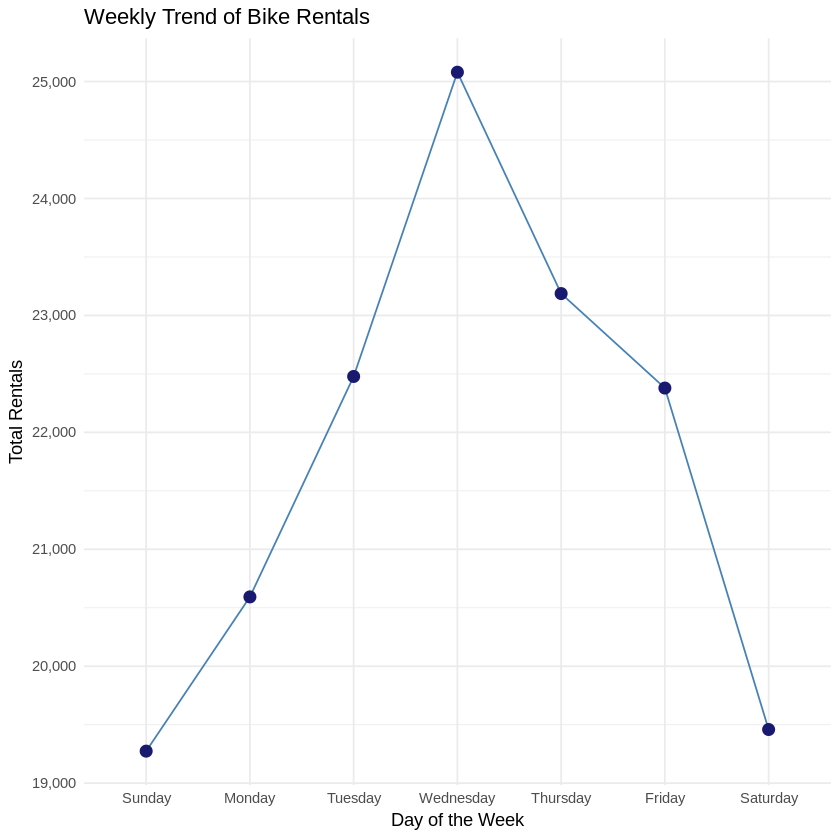

In [52]:
# Create Visualization: Line and Point Plot to show the weekly trend
# Note: group = 1 is required in ggplot when making a line graph with a categorical x-axis
ggplot(day_summary, aes(x = Day.Of.Week, y = Rental_Count, group = 1))+
  geom_line(color = "steelblue")+
  geom_point(color = "midnightblue", size = 3)+
  scale_y_continuous(labels = comma)+
  labs(title = 'Weekly Trend of Bike Rentals',
       x = 'Day of the Week',
       y = 'Total Rentals')+
  theme_minimal()

**Summary of Findings for Question 1:**

The line graph shows a clear weekly pattern in bike share usage. Trips steadily increase from Monday and peak in the middle of the week, with the highest number of rides (25080) occurring on Wednesday. After that, usage drops as the weekend approaches. This pattern supports the idea that most riders are using the bikes for regular weekday commuting rather than for occasional weekend trips.

### Question 2

**What is the average travel time for users in different cities?**

In [53]:
# Numeric Summary comparing means and medians
duration_summary <- combined_data %>%
  group_by(City)%>%
  summarise(Mean_Duration = mean(Trip.Duration, na.rm = TRUE),
            Median_Duration = median(Trip.Duration, na.rm = TRUE)) %>%
  arrange(desc(Mean_Duration))

print("Question 2 Summary:")
print(duration_summary)

[1] "Question 2 Summary:"
# A tibble: 3 x 3
  City       Mean_Duration Median_Duration
  <chr>              <dbl>           <dbl>
1 Washington         1234.            707.
2 Chicago             937.            670 
3 New York            904.            610 


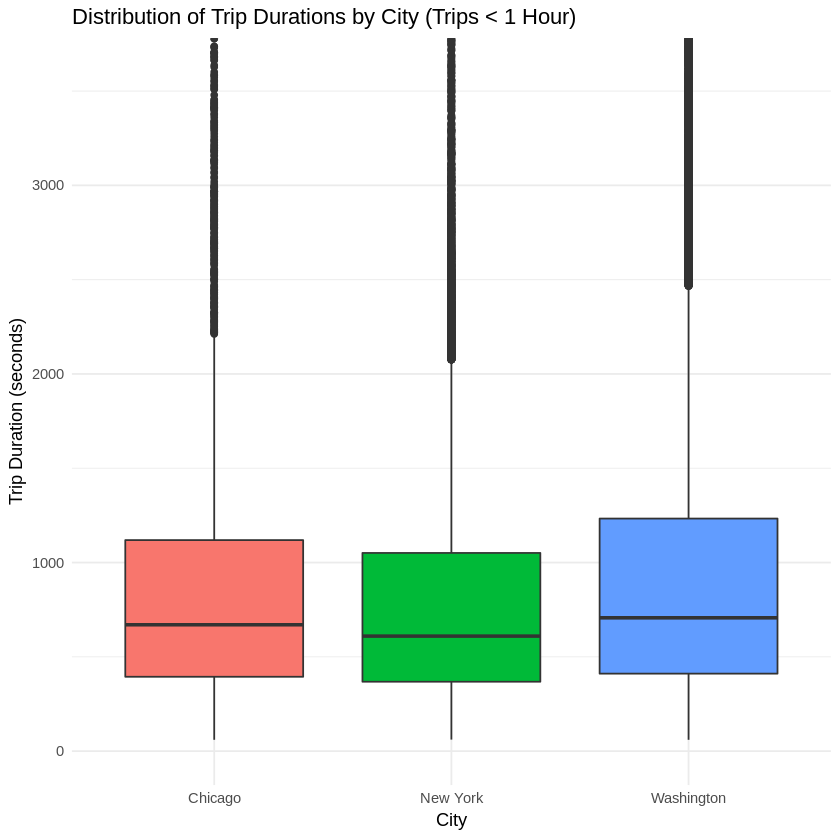

In [54]:
# Create Visualization
# We use the raw 'combined_data' here to show the full distribution
ggplot(combined_data, aes(x = City, y = Trip.Duration, fill = City)) +
  geom_boxplot(na.rm=TRUE)+
  # Zooming in on trips under 1 hour (3600 seconds) to filter out extreme outliers 
  coord_cartesian(ylim = c(0, 3600))+
  labs(title = 'Distribution of Trip Durations by City (Trips < 1 Hour)', 
       x = 'City',
       y = 'Trip Duration (seconds)')+
  theme_minimal()+
  theme(legend.position = 'none')

**Summary of Findings for Question 2:**

When looking at trip duration, Washington has the longest average travel time at about 1,234 seconds (roughly 20 minutes). Chicago follows with an average of 937 seconds, and New York has the shortest average at around 904 seconds. In all three cities, the median trip time is much lower than the average, which suggests the data are right-skewed. This means most trips are fairly short, but a smaller number of much longer trips raise the overall average.

### Question 3

**What are the counts of each user type?**

In [55]:
# Numeric Summary
user_summary <- combined_data %>%
  # Filter out rows where User.Type is empty or NA
  filter(User.Type != "" & !is.na(User.Type)) %>% 
  group_by(City, User.Type) %>%
  summarise(Count = n())

print("Question 3 Summary:")
print(user_summary)

[1] "Question 3 Summary:"
# A tibble: 6 x 3
# Groups:   City [?]
  City       User.Type  Count
  <chr>      <chr>      <int>
1 Chicago    Customer    1746
2 Chicago    Subscriber  6883
3 New York   Customer    5558
4 New York   Subscriber 49093
5 Washington Customer   23450
6 Washington Subscriber 65600


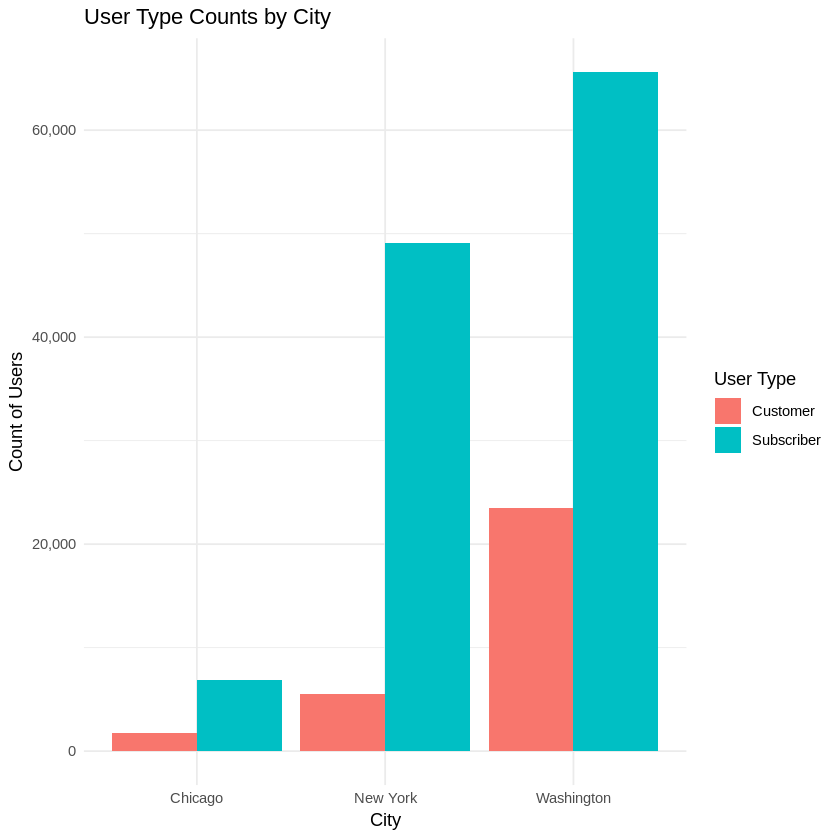

In [56]:
# Create Visualization
ggplot(user_summary, aes(x = City, y = Count, fill = User.Type))+
    scale_y_continuous(labels=comma)+
    geom_col(position = "dodge")+
    labs(title = 'User Type Counts by City',
       x = 'City',
       y = 'Count of Users',
       fill = 'User Type')+
    theme_minimal()

**Summary of Finding for Question 3:**

Across all three cities, the majority of users are Subscribers rather than short-term Customers. Washington has the highest number of subscribers, with a total of 65,600. That leaves Chicago with the least amount of subscribers.


## Finishing Up

> Congratulations!  You have reached the end of the Explore Bikeshare Data Project. You should be very proud of all you have accomplished!

> **Tip**: Once you are satisfied with your work here, check over your report to make sure that it is satisfies all the areas of the [rubric](https://review.udacity.com/#!/rubrics/2508/view). 


## Directions to Submit

> Before you submit your project, you need to create a .html or .pdf version of this notebook in the workspace here. To do that, run the code cell below. If it worked correctly, you should get a return code of 0, and you should see the generated .html file in the workspace directory (click on the orange Jupyter icon in the upper left).

> Alternatively, you can download this report as .html via the **File** > **Download as** submenu, and then manually upload it into the workspace directory by clicking on the orange Jupyter icon in the upper left, then using the Upload button.

> Once you've done this, you can submit your project by clicking on the "Submit Project" button in the lower right here. This will create and submit a zip file with this .ipynb doc and the .html or .pdf version you created. Congratulations!

In [57]:
system('python -m nbconvert Explore_bikeshare_data.ipynb')